# Imports and definitions

In [1]:
# imports
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from numpy import sqrt, pi
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [ ]:
# change the directory to cactus here
CACTUS_ROOT = "/home/undercover/projects/cactus"

In [ ]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl {CACTUS_ROOT}/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Charge vs time

In [13]:
alpha = 0.1

sd   = SimDir(f"../simulations/sextic_lower_alpha={alpha}-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w=0.950_h=4")
ts   = sd.timeseries
gf   = sd.gf
hor  = sd.horizons
muls = sd.multipoles

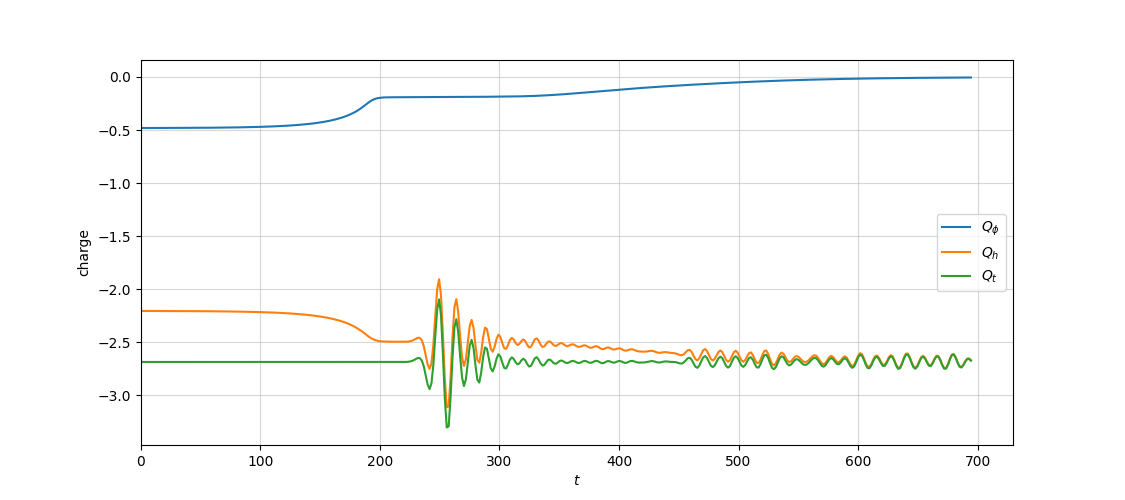

In [15]:
R = 240

Phi1_00 = muls["Phi1"][R][(0,0)]
M_adm   = hor[5,6].adm_energy.y
Q_phi   = ts.scalar["Q_phi"]

# compute the total charge
Q_t = (1/alpha)*(-1 + sqrt(1 + Phi1_00.y.real**2*(M_adm + 2*R)**2))/Phi1_00.y.real

# compute charge at the horizon
Q_h = Q_t - sqrt(4*pi)/alpha*(2*Q_phi.y)

# make the plot
fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))

ax1.plot(Q_phi.t, sqrt(4*pi)/alpha*(2*Q_phi.y), label=r"$Q_\phi$")
ax1.plot(Q_phi.t, Q_h,                          label=r"$Q_h$")
ax1.plot(Q_phi.t, Q_t,                          label=r"$Q_t$")

#ax1.axhline(y=0.90*sqrt(4*pi)/alpha*(2*Q_phi.y[0]), linestyle="dashed", color="grey", alpha=0.75)
#ax1.axhline(y=0.10*sqrt(4*pi)/alpha*(2*Q_phi.y[0]), linestyle="dashed", color="grey", alpha=0.75)

ax1.grid(alpha=0.5)
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"charge")
ax1.set_xlim(left=0)
ax1.legend();

In [7]:
# this is the charge of the scalar field Q_phi
sqrt(4*pi)/alpha*(2*Q_phi.y[0])

-0.48067433591984554

In [9]:
# this is the total charge Q_t
Q_t[0]

-2.6842235796045943

In [10]:
# this is the horizon charge Q_h
Q_h[0]

-2.2035492436847486

In [ ]:
# all is good when compared to the solutions straight out of the elliptic problem! (a t = 0 of course)
# although the oscilation of the charge of the horizon are weird... maybe I'm assuming that the total charge is conserved and it isn't because this is not covariant?